# FINAL Data Analysis: Predictors of Maternal Morbidity
Important as before population itself heavily weighed the distribution of the SHAP number and my findings 


In [1]:
import sys
!{sys.executable} -m pip install --force-reinstall --no-cache-dir numpy scipy shap

   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ------------------------ --------------- 7.9/12.6 MB 44.2 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 49.4 MB/s  0:00:00
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   --------------- ------------------------ 14.4/36.6 MB 69.7 MB/s eta 0:00:01
   ------------------------------ --------- 27.8/36.6 MB 67.8 MB/s eta 0:00:01
   ---------------------------------------- 36.6/36.6 MB 68.4 MB/s  0:00:00
   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ---------------------------------------- 554.9/554.9 kB ?  0:00:00
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ----------- ---------------------------- 12.1/41.9 MB 63.1 MB/s eta 0:00:01
   ------------------------ --------------- 26.0/41.9 MB 63.3 MB/s eta 0:00:01
   -------------------------------------- - 40.1/41.9 MB 65.4 MB/s eta 0:00:01
   ---------------------

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.4.6 which is incompatible.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.17.1 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
!pip install --upgrade catboost
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier, Pool
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay
from sklearn.preprocessing import LabelEncoder


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
def load_and_clean(path):
    df = pd.read_csv(path, dtype=str, engine="python", on_bad_lines="skip")
    df["Births"] = pd.to_numeric(df["Births"], errors="coerce")
    df = df[df["State of Residence"].notna() & df["Births"].notna()]
    df = df[df["Maternal Morbidity Checked"].isin(
        ["At least one checked", "None checked"]
    )]
    return df

df = load_and_clean("../data/raw/query1_raw.csv")
feature_cols = ["State of Residence", "Mother's Single Race 6", 
               "Age of Mother 10", "Mother's Education"]
df["y"] = (df["Maternal Morbidity Checked"] == "At least one checked").astype(int)

X = df[feature_cols]
y = df["y"]
cat_features = feature_cols

#logistic regression only 
X_dummies = pd.get_dummies(X, drop_first = True)



## Part 1.1: Cross-Validating AUC comparison 

In [8]:
kf = KFold (n_splits = 5, shuffle = True, random_state = 42)
logit_aucs, cb_aucs = [], []

for train_idx, test_idx in kf.split(X):
    logit = LogisticRegression(max_iter = 2000)
    logit.fit(X_dummies.iloc[train_idx], y.iloc[train_idx])
    logit_pred = logit.predict_proba(X_dummies.iloc[test_idx])[:, 1]
    logit_aucs.append(roc_auc_score(y.iloc[test_idx], logit_pred))

    cb = CatBoostClassifier(iterations=200, depth=4, learning_rate=0.05, 
                            cat_features = cat_features, verbose = False, 
                            random_state = 42)
    cb.fit(X.iloc[train_idx], y.iloc[train_idx])
    cb_pred = cb.predict_proba(X.iloc[test_idx])[:, 1]
    cb_aucs.append(roc_auc_score(y.iloc[test_idx], cb_pred))

print("Cross-validated AUC (5-fold, unweighted/fair")
print(f"Logistic Regression: {np.mean(logit_aucs):.4f} (+/-{np.std(logit_aucs):.4f})")
print(f"CatBoost:{np.mean(cb_aucs):.4f} (+/- {np.std(cb_aucs):.4f})")
    

Cross-validated AUC (5-fold, unweighted/fair
Logistic Regression: 0.8167 (+/-0.0108)
CatBoost:0.9904 (+/- 0.0022)


## Part 1.2: Forest Plot (Logistic Regression coefficients + 95% CI)

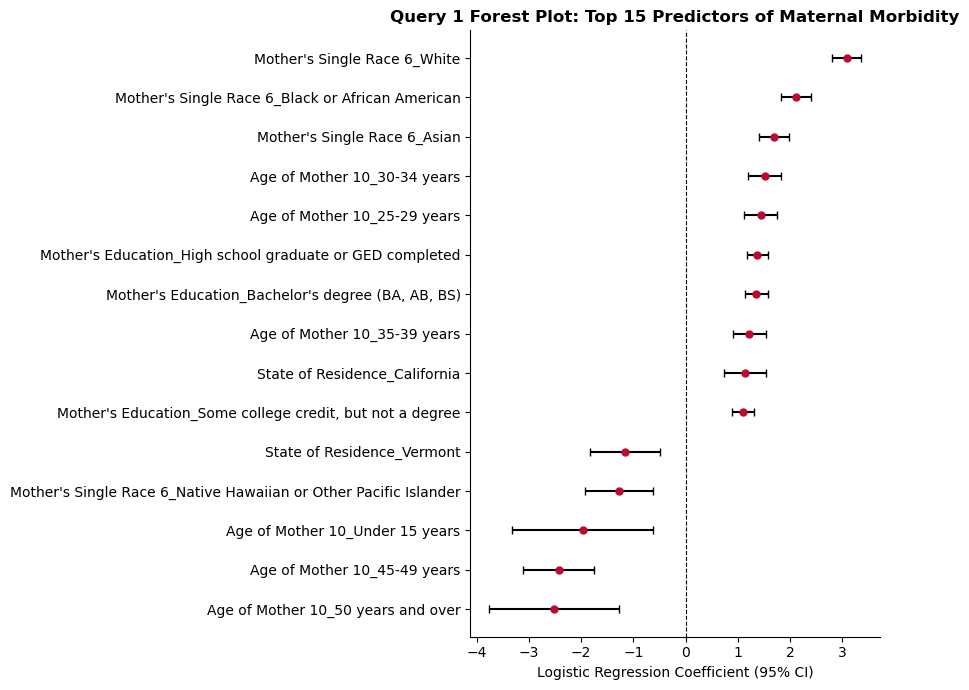

In [9]:
logit_full = LogisticRegression(max_iter = 2000)
logit_full.fit(X_dummies, y)

#approximate standard errors
probs = logit_full.predict_proba(X_dummies)[:, 1]
W = np.diag(probs * (1 - probs))
X_mat = np.column_stack([np.ones(len(X_dummies)), X_dummies.values]).astype(float)
cov = np.linalg.pinv(X_mat.T @ W @ X_mat)
se = np.sqrt(np.diag(cov))[1:] 

coef_table = pd.DataFrame({"coef": logit_full.coef_[0], "se": se}, index=X_dummies.columns)
coef_table["ci95"] = 1.96 * coef_table["se"]
coef_table.to_csv("logit_coefficients_final.csv")

top15 = coef_table.reindex(coef_table["coef"].abs().sort_values(ascending=False).index).head(15)
top15 = top15.sort_values("coef")

fig, ax = plt.subplots(figsize=(9, 7))
ax.errorbar(top15["coef"], top15.index, xerr=top15["ci95"], fmt="o",
            color="#BF0A30", ecolor="black", capsize=3, markersize=5)\

ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Logistic Regression Coefficient (95% CI)")
ax.set_title("Query 1 Forest Plot: Top 15 Predictors of Maternal Morbidity", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("final_forest_plot.png", dpi=200, bbox_inches="tight")
plt.show()


## Part 1.3: SHAP feature importance for CatBoost 

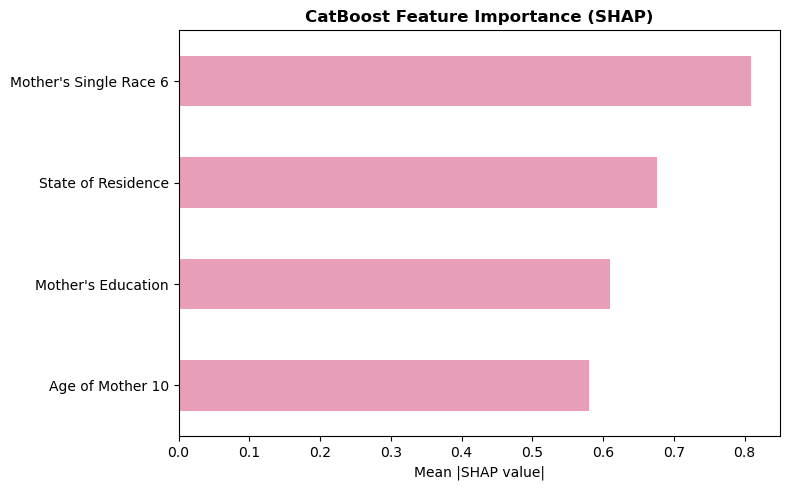


=== Final Summary: Query 1 (Race, Age, Education) ===
Logistic Regression AUC: 0.8167
CatBoost AUC:            0.9904

SHAP importance ranking (CatBoost):
Mother's Single Race 6    0.809597
State of Residence        0.676569
Mother's Education        0.609375
Age of Mother 10          0.580158
dtype: float64

Top logistic regression coefficients (by magnitude):
                                                                      coef  \
Mother's Single Race 6_White                                      3.084544   
Age of Mother 10_50 years and over                               -2.518856   
Age of Mother 10_45-49 years                                     -2.428705   
Mother's Single Race 6_Black or African American                  2.117922   
Age of Mother 10_Under 15 years                                  -1.970384   
Mother's Single Race 6_Asian                                      1.695844   
Age of Mother 10_30-34 years                                      1.519781   
Age of Moth

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
 
cb_final = CatBoostClassifier(iterations=200, depth=4, learning_rate=0.05,
                               cat_features=cat_features, verbose=False, random_state=42)
cb_final.fit(X_train, y_train)
 
shap_values = cb_final.get_feature_importance(
    data=Pool(X_test, cat_features=cat_features), type="ShapValues"
)
shap_values_only = shap_values[:, :-1]  # drop the bias/baseline column
 
shap_importance = pd.Series(
    np.abs(shap_values_only).mean(axis=0), index=feature_cols
).sort_values()


fig, ax = plt.subplots(figsize=(8, 5))
shap_importance.plot.barh(ax=ax, color="#E89EB8")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("CatBoost Feature Importance (SHAP)", fontweight="bold")
plt.tight_layout()
plt.savefig("final_catboost_shap.png", dpi=200, bbox_inches="tight")
plt.show()
 
print("\n=== Final Summary: Query 1 (Race, Age, Education) ===")
print(f"Logistic Regression AUC: {np.mean(logit_aucs):.4f}")
print(f"CatBoost AUC:            {np.mean(cb_aucs):.4f}")
print("\nSHAP importance ranking (CatBoost):")
print(shap_importance.sort_values(ascending=False))
print("\nTop logistic regression coefficients (by magnitude):")
print(top15[["coef", "ci95"]].reindex(top15["coef"].abs().sort_values(ascending=False).index))

## Part 2.1: Query 2 (Urbanicity, Hispanic Origin, Insurance)

In [12]:
QUERY2_PATH = "../data/raw/query2_raw.csv"

df2 = load_and_clean(QUERY2_PATH)
feature_cols_2 = ["State of Residence", "2023 Metro/Nonmetro",
                   "Mother's Hispanic Origin", "Source of Payment for Delivery"]
df2["y"] = (df2["Maternal Morbidity Checked"] == "At least one checked").astype(int)
 
X2 = df2[feature_cols_2]
y2 = df2["y"]
cat_features_2 = feature_cols_2
X2_dummies = pd.get_dummies(X2, drop_first=True)
 
# --- Cross-validated AUC ---
logit2_aucs, cb2_aucs = [], []
for train_idx, test_idx in kf.split(X2):
    logit2 = LogisticRegression(max_iter=2000)
    logit2.fit(X2_dummies.iloc[train_idx], y2.iloc[train_idx])
    pred = logit2.predict_proba(X2_dummies.iloc[test_idx])[:, 1]
    logit2_aucs.append(roc_auc_score(y2.iloc[test_idx], pred))
 
    cb2 = CatBoostClassifier(iterations=200, depth=4, learning_rate=0.05,
                              cat_features=cat_features_2, verbose=False, random_state=42)
    cb2.fit(X2.iloc[train_idx], y2.iloc[train_idx])
    pred_cb = cb2.predict_proba(X2.iloc[test_idx])[:, 1]
    cb2_aucs.append(roc_auc_score(y2.iloc[test_idx], pred_cb))
 
print("\n=== Query 2: Cross-validated AUC (5-fold, unweighted/fair) ===")
print(f"Logistic Regression: {np.mean(logit2_aucs):.4f} (+/- {np.std(logit2_aucs):.4f})")
print(f"CatBoost:             {np.mean(cb2_aucs):.4f} (+/- {np.std(cb2_aucs):.4f})")


=== Query 2: Cross-validated AUC (5-fold, unweighted/fair) ===
Logistic Regression: 0.6593 (+/- 0.0191)
CatBoost:             0.9768 (+/- 0.0075)


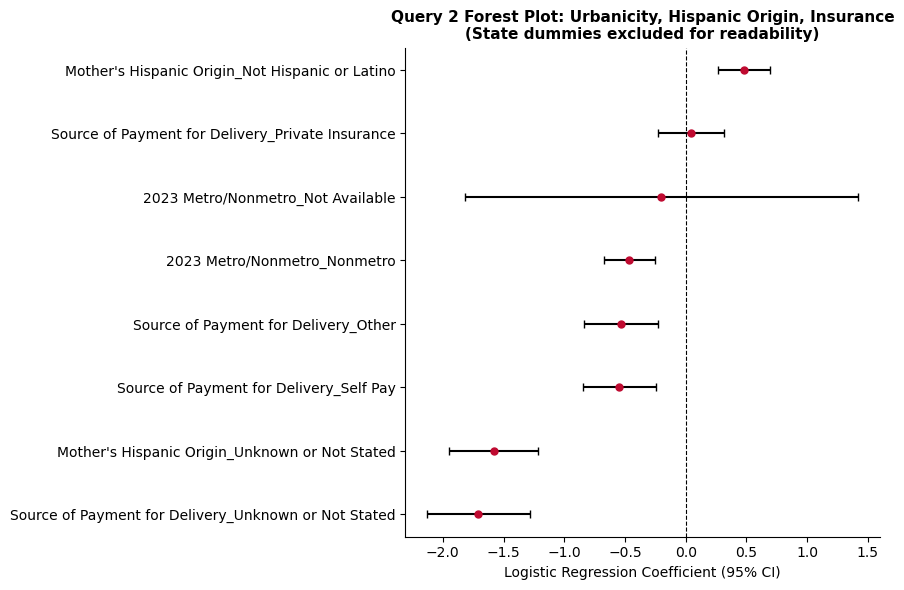

In [13]:
logit2_full = LogisticRegression(max_iter=2000)
logit2_full.fit(X2_dummies, y2)
probs2 = logit2_full.predict_proba(X2_dummies)[:, 1]
W2 = np.diag(probs2 * (1 - probs2))
X2_mat = np.column_stack([np.ones(len(X2_dummies)), X2_dummies.values]).astype(float)
cov2 = np.linalg.pinv(X2_mat.T @ W2 @ X2_mat)
se2 = np.sqrt(np.diag(cov2))[1:]
 
coef_table2 = pd.DataFrame({"coef": logit2_full.coef_[0], "se": se2}, index=X2_dummies.columns)
coef_table2["ci95"] = 1.96 * coef_table2["se"]
coef_table2.to_csv("logit_coefficients_query2_final.csv")
 
non_state = coef_table2[~coef_table2.index.str.startswith("State of Residence")].sort_values("coef")
fig, ax = plt.subplots(figsize=(9, 6))

ax.errorbar(non_state["coef"], non_state.index, xerr=non_state["ci95"], fmt="o",
            color="#BF0A30", ecolor="black", capsize=3, markersize=5)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Logistic Regression Coefficient (95% CI)")
ax.set_title("Query 2 Forest Plot: Urbanicity, Hispanic Origin, Insurance\n(State dummies excluded for readability)",
             fontweight="bold", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("final_forest_plot_query2.png", dpi=200, bbox_inches="tight")
plt.show()

## Part 2.2: SHAP for Query 2 CatBoost


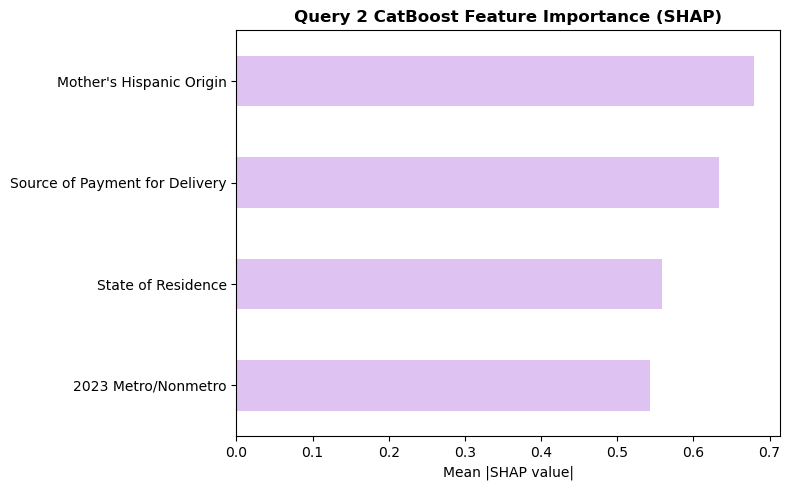


=== Final Summary: Query 2 (Urbanicity, Hispanic Origin, Insurance) ===
Logistic Regression AUC: 0.6593
CatBoost AUC:            0.9768

SHAP importance ranking (CatBoost):
Mother's Hispanic Origin          0.679571
Source of Payment for Delivery    0.633818
State of Residence                0.558180
2023 Metro/Nonmetro               0.542898
dtype: float64


In [14]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)
cb2_final = CatBoostClassifier(iterations=200, depth=4, learning_rate=0.05,
                                cat_features=cat_features_2, verbose=False, random_state=42)
cb2_final.fit(X2_train, y2_train)
 
shap_values2 = cb2_final.get_feature_importance(
    data=Pool(X2_test, cat_features=cat_features_2), type="ShapValues"
)
shap_importance2 = pd.Series(
    np.abs(shap_values2[:, :-1]).mean(axis=0), index=feature_cols_2
).sort_values()
 
fig, ax = plt.subplots(figsize=(8, 5))
shap_importance2.plot.barh(ax=ax, color="#DDC2F2")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Query 2 CatBoost Feature Importance (SHAP)", fontweight="bold")
plt.tight_layout()
plt.savefig("final_catboost_shap_query2.png", dpi=200, bbox_inches="tight")
plt.show()
 
print("\n=== Final Summary: Query 2 (Urbanicity, Hispanic Origin, Insurance) ===")
print(f"Logistic Regression AUC: {np.mean(logit2_aucs):.4f}")
print(f"CatBoost AUC:            {np.mean(cb2_aucs):.4f}")
print("\nSHAP importance ranking (CatBoost):")
print(shap_importance2.sort_values(ascending=False))

## Part 3: Beeswarm Plots for Q1 & Q2

### Query 1 Beeswarm Plot

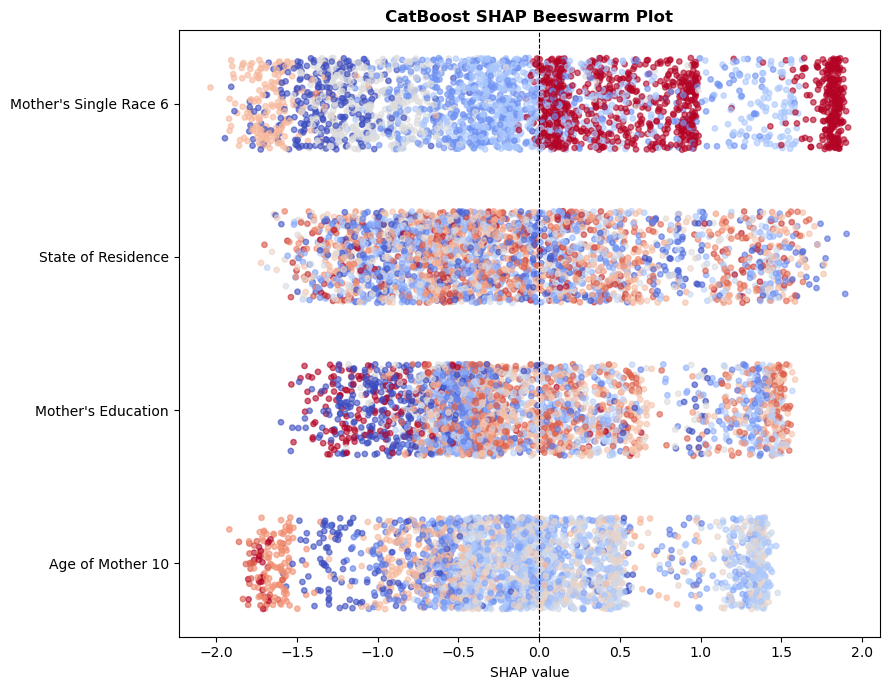

In [25]:
shap_values = cb_final.get_feature_importance(
    data=Pool(X_test, cat_features=cat_features), type="ShapValues"
)
shap_values_only = shap_values[:, :-1]  # drop the bias/baseline column

fig, ax = plt.subplots(figsize=(9, 7))

# Order features by overall importance (mean |SHAP|), smallest at bottom
importance_order = np.argsort(np.abs(shap_values_only).mean(axis=0))

for rank, feat_idx in enumerate(importance_order):
    feat_name = feature_cols[feat_idx]
    values = shap_values_only[:, feat_idx]

    # Color by category, since these are all categorical (no natural low/high order)
    le = LabelEncoder()
    color_vals = le.fit_transform(X_test[feat_name].astype(str))

    # Add small random vertical jitter so overlapping dots are visible
    y_jitter = rank + np.random.uniform(-0.3, 0.3, size=len(values))

    sc = ax.scatter(values, y_jitter, c=color_vals, cmap="coolwarm", s=15, alpha=0.6)

ax.set_yticks(range(len(feature_cols)))
ax.set_yticklabels([feature_cols[i] for i in importance_order])
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("SHAP value")
ax.set_title("CatBoost SHAP Beeswarm Plot", fontweight="bold")
plt.tight_layout()
plt.savefig("shap_beeswarm_manual.png", dpi=200, bbox_inches="tight")
plt.show()

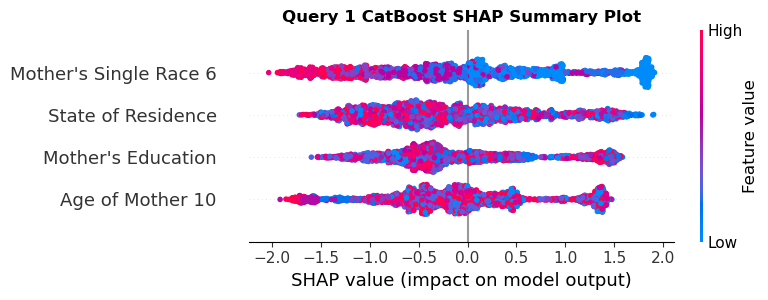

In [27]:
# Remove CatBoost's final base-value column
shap_values_plot = shap_values[:, :-1]

# Create numeric values ONLY for visualization
X_test_numeric = X_test[feature_cols].copy()

for col in feature_cols:
    X_test_numeric[col] = pd.factorize(X_test_numeric[col])[0]

# Convert to a NumPy array so SHAP treats the values as continuous
X_test_numeric = X_test_numeric.to_numpy(dtype=float)

# SHAP beeswarm / summary plot
shap.summary_plot(
    shap_values_plot,
    X_test_numeric,
    feature_names=feature_cols,
    plot_type="dot",
    show=False
)

plt.title("Query 1 CatBoost SHAP Summary Plot", fontweight="bold")
plt.tight_layout()

plt.savefig(
    "final_catboost_shap_beeswarm_q1.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### Query 2 Beeswarm Plot

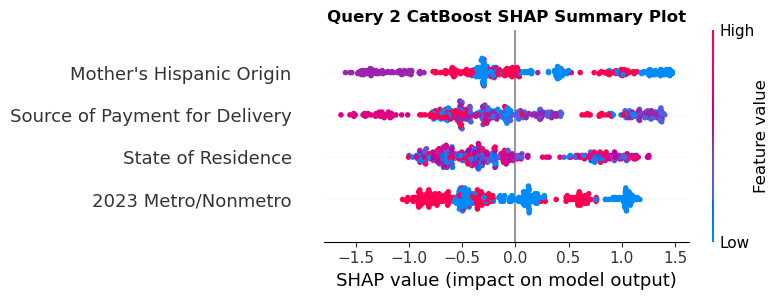

In [22]:
# Remove CatBoost's final base-value column
shap_values2_plot = shap_values2[:, :-1]

# Create numeric values ONLY for visualization
X2_test_numeric = X2_test[feature_cols_2].copy()

for col in feature_cols_2:
    X2_test_numeric[col] = pd.factorize(X2_test_numeric[col])[0]

# Convert to a NumPy array so SHAP treats the values as continuous
X2_test_numeric = X2_test_numeric.to_numpy(dtype=float)

# SHAP beeswarm / summary plot
shap.summary_plot(
    shap_values2_plot,
    X2_test_numeric,
    feature_names=feature_cols_2,
    plot_type="dot",
    show=False
)

plt.title("Query 2 CatBoost SHAP Summary Plot", fontweight="bold")
plt.tight_layout()

plt.savefig(
    "final_catboost_shap_beeswarm_query2.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()